# Radius Search Results Overview

This notebook summarizes the results from `scripts/06_search_radius_hyperparams.py`. It shows: overall experiment results, per-radius results, fold-specific results across all radii, and a chart of test AUC versus radius.

Expected input folder: the root folder that contains one subfolder per experiment, each with a `radius_search_summary.json` file.

In [34]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 80)

def pick_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]

CANDIDATE_RESULTS_ROOTS = [
    Path('/mnt/e/data/radius_search'),
    Path('E:/data/radius_search'),
    Path('data/radius_search'),
]
RESULTS_ROOT = pick_existing_path(CANDIDATE_RESULTS_ROOTS)
RESULTS_ROOT

WindowsPath('E:/data/radius_search')

In [35]:
def format_fold_with_session(fold: int) -> str:
    fold_to_session = {
        0: "030326",
        1: "230226",
        2: "260326_part1 & 260326_part2",
        3: "280126",
        4: "300925",
    }
    
    session = fold_to_session.get(fold, "unknown")
    return f"Fold {fold} (session {session})"
def load_json(path):
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)

def mean_metric_from_entries(entries, metric_name, nested_key='test_metrics'):
    values = []
    for entry in entries:
        if nested_key is None:
            value = entry.get(metric_name)
        else:
            nested = entry.get(nested_key, {})
            value = nested.get(metric_name)
        if value is not None:
            values.append(float(value))
    if not values:
        return None
    return float(pd.Series(values).mean())

def experiment_row(summary_path, summary):
    return {
        'experiment': summary.get('experiment', summary_path.parent.name),
        'summary_path': str(summary_path),
        'best_radius_by_mean_val_auc': summary.get('best_radius_by_mean_val_auc'),
        'best_radius_mean_val_auc': summary.get('best_radius_mean_val_auc'),
        'selected_mean_test_auc': summary.get('selected_mean_test_auc'),
        'selected_mean_test_loss': summary.get('selected_mean_test_loss'),
        'selected_mean_test_acc': summary.get('selected_mean_test_acc') if summary.get('selected_mean_test_acc') is not None else mean_metric_from_entries(summary.get('selected_fold_results', []), 'acc'),
        'selected_mean_test_precision': summary.get('selected_mean_test_precision') if summary.get('selected_mean_test_precision') is not None else mean_metric_from_entries(summary.get('selected_fold_results', []), 'precision'),
        'selected_mean_test_recall': summary.get('selected_mean_test_recall') if summary.get('selected_mean_test_recall') is not None else mean_metric_from_entries(summary.get('selected_fold_results', []), 'recall'),
        'num_radii': len(summary.get('radius_results', [])),
    }

def radius_rows(summary, experiment_name):
    rows = []
    for entry in summary.get('radius_results', []):
        rows.append({
            'experiment': experiment_name,
            'radius_km': entry.get('radius_km'),
            'mean_best_val_auc': entry.get('mean_best_val_auc'),
            'mean_test_auc': entry.get('mean_test_auc'),
            'mean_test_loss': entry.get('mean_test_loss'),
            'mean_test_acc': entry.get('mean_test_acc') if entry.get('mean_test_acc') is not None else mean_metric_from_entries(entry.get('fold_results', []), 'acc'),
            'mean_test_precision': entry.get('mean_test_precision') if entry.get('mean_test_precision') is not None else mean_metric_from_entries(entry.get('fold_results', []), 'precision'),
            'mean_test_recall': entry.get('mean_test_recall') if entry.get('mean_test_recall') is not None else mean_metric_from_entries(entry.get('fold_results', []), 'recall'),
        })
    return rows

def fold_rows(summary, experiment_name, fold_id):
    rows = []
    for entry in summary.get('radius_results', []):
        matching = next((item for item in entry.get('fold_results', []) if item.get('fold_id') == fold_id), None)
        if matching is None:
            continue
        metrics = matching.get('test_metrics', {})
        rows.append({
            'experiment': experiment_name,
            'fold_id': format_fold_with_session(fold_id),
            'radius_km': entry.get('radius_km'),
            'best_val_auc': matching.get('best_val_auc'),
            'best_val_loss': matching.get('best_val_loss'),
            'test_auc': metrics.get('auc'),
            'test_loss': metrics.get('loss'),
            'test_acc': metrics.get('acc'),
            'test_precision': metrics.get('precision'),
            'test_recall': metrics.get('recall'),
        })
    return rows

search_summary_paths = sorted(RESULTS_ROOT.glob('*/radius_search_summary.json'))
if not search_summary_paths:
    raise FileNotFoundError(f'No radius_search_summary.json files found under {RESULTS_ROOT}')

summaries = []
experiment_rows = []
radius_rows_all = []
summaries_by_experiment = {}

for summary_path in search_summary_paths:
    summary = load_json(summary_path)
    experiment_name = summary.get('experiment', summary_path.parent.name)
    summaries.append((summary_path, summary))
    summaries_by_experiment[experiment_name] = (summary_path, summary)
    experiment_rows.append(experiment_row(summary_path, summary))
    radius_rows_all.extend(radius_rows(summary, experiment_name))

experiment_df = pd.DataFrame(experiment_rows).sort_values('best_radius_mean_val_auc', ascending=False).reset_index(drop=True)
radius_df = pd.DataFrame(radius_rows_all).sort_values(['experiment', 'radius_km']).reset_index(drop=True)

experiment_df

,experiment,summary_path,best_radius_by_mean_val_auc,best_radius_mean_val_auc,selected_mean_test_auc,selected_mean_test_loss,selected_mean_test_acc,selected_mean_test_precision,selected_mean_test_recall,num_radii
0,aero_aug_noise_to_norwegian,E:\data\radius_search\aero_aug_noise_to_norwegian\radius_search_summary.json,3.0,0.747757,0.562585,0.769026,0.484978,0.243921,0.575164,8


In [36]:
display(Markdown('## Overall experiment summary'))
display(experiment_df)

display(Markdown('## Per-radius tables'))
for experiment_name in experiment_df['experiment']:
    display(Markdown(f'### {experiment_name}'))
    subset = radius_df[radius_df['experiment'] == experiment_name].copy().sort_values('radius_km').reset_index(drop=True)
    display(subset)

display(Markdown('## Best three radii per experiment'))
top_radii = (
    radius_df.sort_values(['experiment', 'mean_best_val_auc'], ascending=[True, False])
    .groupby('experiment', as_index=False)
    .head(3)
)
display(top_radii.reset_index(drop=True))

## Overall experiment summary

,experiment,summary_path,best_radius_by_mean_val_auc,best_radius_mean_val_auc,selected_mean_test_auc,selected_mean_test_loss,selected_mean_test_acc,selected_mean_test_precision,selected_mean_test_recall,num_radii
0,aero_aug_noise_to_norwegian,E:\data\radius_search\aero_aug_noise_to_norwegian\radius_search_summary.json,3.0,0.747757,0.562585,0.769026,0.484978,0.243921,0.575164,8


## Per-radius tables

### aero_aug_noise_to_norwegian

,experiment,radius_km,mean_best_val_auc,mean_test_auc,mean_test_loss,mean_test_acc,mean_test_precision,mean_test_recall
0,aero_aug_noise_to_norwegian,1.0,0.426190,0.460129,1.449127,0.220196,0.024360,0.598773
1,aero_aug_noise_to_norwegian,2.0,0.628389,0.620536,1.161234,0.437764,0.108445,0.414634
2,aero_aug_noise_to_norwegian,3.0,0.747757,0.766402,0.747907,0.819129,0.299652,0.177984
3,aero_aug_noise_to_norwegian,4.0,0.674546,0.689810,1.249085,0.190080,0.190080,1.000000
4,aero_aug_noise_to_norwegian,5.0,0.626399,0.624647,0.907557,0.410159,0.390673,0.801003
5,aero_aug_noise_to_norwegian,6.0,0.672386,0.642811,1.095239,0.495915,0.467740,0.966724
6,aero_aug_noise_to_norwegian,7.0,0.627641,0.579074,0.964394,0.521423,0.491413,0.885012
7,aero_aug_noise_to_norwegian,8.0,0.584323,0.579928,1.023579,0.476296,0.543535,0.800738


## Best three radii per experiment

,experiment,radius_km,mean_best_val_auc,mean_test_auc,mean_test_loss,mean_test_acc,mean_test_precision,mean_test_recall
0,aero_aug_noise_to_norwegian,3.0,0.747757,0.766402,0.747907,0.819129,0.299652,0.177984
1,aero_aug_noise_to_norwegian,4.0,0.674546,0.689810,1.249085,0.190080,0.190080,1.000000
2,aero_aug_noise_to_norwegian,6.0,0.672386,0.642811,1.095239,0.495915,0.467740,0.966724


In [37]:
fold_comparison_rows = []
for experiment_name, (_, selected_summary) in summaries_by_experiment.items():
    for radius_entry in selected_summary.get('radius_results', []):
        radius_km = radius_entry.get('radius_km')
        for fold_entry in radius_entry.get('fold_results', []):
            metrics = fold_entry.get('test_metrics', {})
            fold_id = fold_entry.get('fold_id')
            fold_comparison_rows.append({
                'experiment': experiment_name,
                'radius_km': radius_km,
                'fold_id': format_fold_with_session(fold_id),
                'best_val_auc': fold_entry.get('best_val_auc'),
                'best_val_loss': fold_entry.get('best_val_loss'),
                'test_auc': metrics.get('auc'),
                'test_loss': metrics.get('loss'),
                'test_acc': metrics.get('acc'),
                'test_precision': metrics.get('precision'),
                'test_recall': metrics.get('recall'),
            })

fold_comparison_df = pd.DataFrame(fold_comparison_rows)
if fold_comparison_df.empty:
    raise ValueError('No fold comparison data found.')

display(Markdown('## All folds across radii'))
for experiment_name in experiment_df['experiment']:
    exp_df = fold_comparison_df[fold_comparison_df['experiment'] == experiment_name].copy().sort_values(['fold_id', 'radius_km']).reset_index(drop=True)
    if exp_df.empty:
        continue

    display(Markdown(f'### {experiment_name}'))
    display(exp_df)

    fold_summary_rows = []
    for fold_formatted, fold_df in exp_df.groupby('fold_id'):
        best_row = fold_df.sort_values('test_auc', ascending=False).iloc[0]
        fold_summary_rows.append({
            'fold_id': fold_formatted,
            'mean_test_auc': fold_df['test_auc'].astype(float).mean(),
            'mean_test_loss': fold_df['test_loss'].astype(float).mean(),
            'mean_test_acc': fold_df['test_acc'].astype(float).mean(),
            'mean_test_precision': fold_df['test_precision'].astype(float).mean(),
            'mean_test_recall': fold_df['test_recall'].astype(float).mean(),
            'best_radius_by_mean_test_auc': float(best_row['radius_km']),
            'best_test_auc': float(best_row['test_auc']),
        })

    fold_summary_df = pd.DataFrame(fold_summary_rows).sort_values('mean_test_auc', ascending=False).reset_index(drop=True)
    display(Markdown(f'#### Fold summary for {experiment_name}'))
    display(fold_summary_df)

    best_fold_per_radius_df = (
        exp_df.sort_values(['radius_km', 'test_auc'], ascending=[True, False])
        .groupby('radius_km', as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    display(Markdown(f'#### Best fold per radius for {experiment_name}'))
    display(best_fold_per_radius_df[['radius_km', 'fold_id', 'best_val_auc', 'test_auc', 'test_loss', 'test_acc', 'test_precision', 'test_recall']].reset_index(drop=True))

## All folds across radii

### aero_aug_noise_to_norwegian

,experiment,radius_km,fold_id,best_val_auc,best_val_loss,test_auc,test_loss,test_acc,test_precision,test_recall
0,aero_aug_noise_to_norwegian,1.0,Fold 0 (session 030326),0.000000,0.750960,0.000000,0.794303,0.000625,0.000000,0.000000
1,aero_aug_noise_to_norwegian,2.0,Fold 0 (session 030326),0.883254,0.949977,0.000000,1.018723,0.000000,0.000000,0.000000
2,aero_aug_noise_to_norwegian,3.0,Fold 0 (session 030326),0.809373,0.557203,0.776128,0.583522,0.973766,0.000000,0.000000
3,aero_aug_noise_to_norwegian,4.0,Fold 0 (session 030326),0.714197,1.266150,0.844213,1.583968,0.033729,0.033729,1.000000
4,aero_aug_noise_to_norwegian,5.0,Fold 0 (session 030326),0.550243,1.202339,0.836911,1.301413,0.325109,0.325109,1.000000
5,aero_aug_noise_to_norwegian,6.0,Fold 0 (session 030326),0.602965,0.716502,0.810249,0.606874,0.733604,0.592730,0.833622
6,aero_aug_noise_to_norwegian,7.0,Fold 0 (session 030326),0.491467,0.833120,0.466367,0.938379,0.418176,0.418176,1.000000
7,aero_aug_noise_to_norwegian,8.0,Fold 0 (session 030326),0.419002,0.806433,0.725809,1.369580,0.458151,0.458151,1.000000
8,aero_aug_noise_to_norwegian,1.0,Fold 1 (session 230226),0.582080,0.618264,0.000000,0.617345,0.957146,0.000000,0.000000
9,aero_aug_noise_to_norwegian,2.0,Fold 1 (session 230226),0.565329,0.307258,0.869606,0.308466,0.979384,0.315789,0.073171


#### Fold summary for aero_aug_noise_to_norwegian

,fold_id,mean_test_auc,mean_test_loss,mean_test_acc,mean_test_precision,mean_test_recall,best_radius_by_mean_test_auc,best_test_auc
0,Fold 4 (session 300925),0.777668,0.966047,0.576543,0.633630,0.874979,1.0,0.937438
1,Fold 3 (session 280126),0.659035,1.359051,0.425483,0.209175,0.783358,1.0,0.859704
2,Fold 1 (session 230226),0.575744,0.673808,0.613765,0.365034,0.389486,2.0,0.869606
3,Fold 0 (session 030326),0.557460,1.024595,0.367895,0.228487,0.604203,4.0,0.844213
4,Fold 2 (session 260326_part1 & 260326_part2),0.532178,1.350325,0.248164,0.136110,0.876016,3.0,0.612812


#### Best fold per radius for aero_aug_noise_to_norwegian

,radius_km,fold_id,best_val_auc,test_auc,test_loss,test_acc,test_precision,test_recall
0,1.0,Fold 4 (session 300925),0.000000,0.937438,0.734755,0.140704,0.119293,0.993865
1,2.0,Fold 1 (session 230226),0.565329,0.869606,0.308466,0.979384,0.315789,0.073171
2,3.0,Fold 1 (session 230226),0.594853,0.862848,0.148273,0.965022,0.357143,0.034014
3,4.0,Fold 0 (session 030326),0.714197,0.844213,1.583968,0.033729,0.033729,1.000000
4,5.0,Fold 0 (session 030326),0.550243,0.836911,1.301413,0.325109,0.325109,1.000000
5,6.0,Fold 0 (session 030326),0.602965,0.810249,0.606874,0.733604,0.592730,0.833622
6,7.0,Fold 4 (session 300925),0.735421,0.784510,0.541008,0.803302,0.803302,1.000000
7,8.0,Fold 0 (session 030326),0.419002,0.725809,1.369580,0.458151,0.458151,1.000000


## Fold comparison chart

This chart shows test AUC for every fold across all radii, so you can compare which fold behaves best as the radius changes.

### aero_aug_noise_to_norwegian

radius_km,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
fold_id,,,,,,,,
Fold 0 (session 030326),0.000000,0.000000,0.776128,0.844213,0.836911,0.810249,0.466367,0.725809
Fold 1 (session 230226),0.000000,0.869606,0.862848,0.646197,0.597346,0.601685,0.563228,0.465044
Fold 2 (session 260326_part1 & 260326_part2),0.503504,0.599479,0.612812,0.526166,0.513602,0.516108,0.489957,0.495795
Fold 3 (session 280126),0.859704,0.847875,0.776528,0.628486,0.458226,0.615972,0.591308,0.494183
Fold 4 (session 300925),0.937438,0.785720,0.803691,0.803987,0.717148,0.670042,0.784510,0.718810


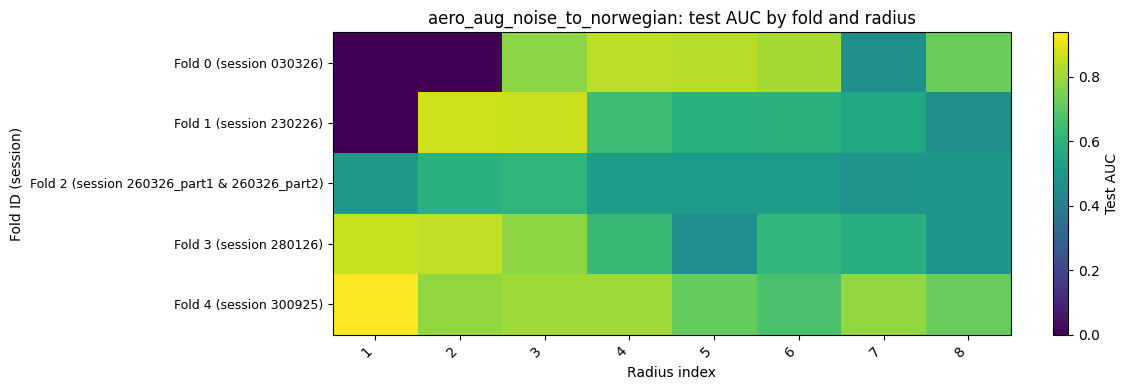

### Best fold per radius for aero_aug_noise_to_norwegian

,radius_km,fold_id,best_val_auc,test_auc,test_loss,test_acc,test_precision,test_recall
0,1.0,Fold 4 (session 300925),0.000000,0.937438,0.734755,0.140704,0.119293,0.993865
1,2.0,Fold 1 (session 230226),0.565329,0.869606,0.308466,0.979384,0.315789,0.073171
2,3.0,Fold 1 (session 230226),0.594853,0.862848,0.148273,0.965022,0.357143,0.034014
3,4.0,Fold 0 (session 030326),0.714197,0.844213,1.583968,0.033729,0.033729,1.000000
4,5.0,Fold 0 (session 030326),0.550243,0.836911,1.301413,0.325109,0.325109,1.000000
5,6.0,Fold 0 (session 030326),0.602965,0.810249,0.606874,0.733604,0.592730,0.833622
6,7.0,Fold 4 (session 300925),0.735421,0.784510,0.541008,0.803302,0.803302,1.000000
7,8.0,Fold 0 (session 030326),0.419002,0.725809,1.369580,0.458151,0.458151,1.000000


In [38]:
if fold_comparison_df.empty:
    raise ValueError('No fold comparison data loaded.')

for experiment_name in experiment_df['experiment']:
    exp_data = fold_comparison_df[fold_comparison_df['experiment'] == experiment_name].copy()
    if exp_data.empty:
        continue

    pivot = exp_data.pivot_table(index='fold_id', columns='radius_km', values='test_auc', aggfunc='mean')
    display(Markdown(f'### {experiment_name}'))
    display(pivot)

    fig, ax = plt.subplots(figsize=(12, max(4, 0.55 * len(pivot))))
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
    ax.set_title(f'{experiment_name}: test AUC by fold and radius')
    ax.set_xlabel('Radius index')
    ax.set_ylabel('Fold ID (session)')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{float(col):g}' for col in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(idx) for idx in pivot.index], fontsize=9)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Test AUC')
    plt.tight_layout()
    plt.show()

    best_folds = exp_data.sort_values(['radius_km', 'test_auc'], ascending=[True, False]).groupby('radius_km', as_index=False).head(1)
    display(Markdown(f'### Best fold per radius for {experiment_name}'))
    display(best_folds[['radius_km', 'fold_id', 'best_val_auc', 'test_auc', 'test_loss', 'test_acc', 'test_precision', 'test_recall']].reset_index(drop=True))